# Experimental Semantic Mapping of Headlines

## Prep two datasets to look at

In [16]:
import pandas as pd
us_df = pd.read_csv('mc-onlinenews-mediacloud-20260308030840-content.csv')
us_df['group'] = 'US'
uk_df = pd.read_csv('mc-onlinenews-mediacloud-20260308030839-content.csv')
uk_df['group'] = 'UK'
combined_df = pd.concat([us_df, uk_df], ignore_index=True)
combined_df.to_csv('combined-data.csv', index=False)

## Add embeddings to the combined dataframe

In [17]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [18]:
headlines = combined_df['title'].tolist()
embeddings = model.encode(headlines, batch_size=64, show_progress_bar=True)

Batches:   0%|          | 0/147 [00:00<?, ?it/s]

## Cluster based on the embeddings

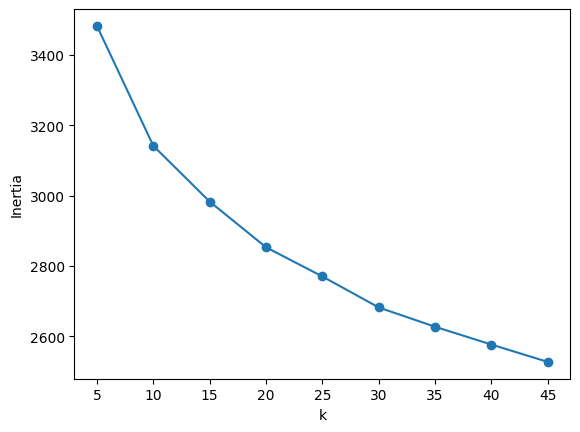

In [19]:
# try elbow method to pick number of clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

embeddings_50d = PCA(n_components=50).fit_transform(embeddings) # speed optimization

inertias = []
ks = range(5, 50, 5)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(embeddings_50d)
    inertias.append(km.inertia_)

plt.plot(ks, inertias, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

In [20]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

km = KMeans(n_clusters=15, random_state=42, n_init="auto")
embeddings_100d = PCA(n_components=100).fit_transform(embeddings) # speed optimization
labels = km.fit_predict(embeddings_100d)
combined_df['label'] = labels

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(headlines)
terms = vectorizer.get_feature_names_out()

for cluster_id in sorted(combined_df['label'].unique()):
    mask = (combined_df['label'] == cluster_id).to_numpy()
    cluster_tfidf = tfidf_matrix[mask].mean(axis=0).A1
    top_terms = terms[cluster_tfidf.argsort()[-3:][::-1]]
    print(f"Cluster {cluster_id}: {', '.join(top_terms)}")
    # take these to Claude and let it name them while creating user interface for browsing clusters

Cluster 0: hormuz, strait, oil
Cluster 1: trump, war, maga
Cluster 2: middle, east, dubai
Cluster 3: iran, strikes, missiles
Cluster 4: stocks, market, markets
Cluster 5: trump, iran, war
Cluster 6: starmer, keir, trump
Cluster 7: iran, cup, iranian
Cluster 8: drone, dubai, iranian
Cluster 9: iran, war, conflict
Cluster 10: iran, trump, strikes
Cluster 11: ai, news, texas
Cluster 12: khamenei, leader, ayatollah
Cluster 13: israel, iran, israeli
Cluster 14: oil, prices, iran


## Reduce the dimensions for display

In [24]:
import umap
reducer = umap.UMAP(n_components=2, n_neighbors=10, random_state=42)
embeddings_2d = reducer.fit_transform(embeddings)

/opt/homebrew/Caskroom/miniforge/base/envs/jupyter/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniforge/base/envs/jupyter/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/opt/homebrew/Caskroom/miniforge/base/envs/jupyter/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/opt/homebrew/Caskroom/miniforge/base/envs/jupyter/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The

In [25]:
combined_df['x'] = [e[0] for e in embeddings_2d]
combined_df['y'] = [e[1] for e in embeddings_2d]
combined_df.to_csv('combined-data-for-display.csv', index=False)